In [ ]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
# Upload the Car Evaluation CSV file from your computer

from google.colab import files

uploaded = files.upload()


Saving car_evaluation.csv to car_evaluation.csv


In [ ]:
# Get the uploaded file name automatically and load the dataset

import pandas as pd

filename = next(iter(uploaded))

df = pd.read_csv(filename)

# Display the first 5 rows
df.head()


,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [ ]:
# Display the number of rows and columns
print("Shape of dataset:", df.shape)

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

# Display information about the dataset
print("\nDataset information:")
df.info()


Shape of dataset: (1727, 7)

Column names:
['vhigh', 'vhigh.1', '2', '2.1', 'small', 'low', 'unacc']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   vhigh    1727 non-null   object
 1   vhigh.1  1727 non-null   object
 2   2        1727 non-null   object
 3   2.1      1727 non-null   object
 4   small    1727 non-null   object
 5   low      1727 non-null   object
 6   unacc    1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [ ]:
# Set column names for the Car Evaluation dataset
# This is useful if the CSV file does not already have proper column names

df.columns = [
    "buying",
    "maint",
    "doors",
    "persons",
    "lug_boot",
    "safety",
    "class"
]

# Display the first 5 rows
df.head()


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [ ]:
# Check the number of missing values in each column

print(df.isnull().sum())


buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64


In [ ]:
# Fill missing values with the most frequent value (mode) of each column

df = df.fillna(df.mode().iloc[0])

# Check again for missing values
print(df.isnull().sum())


buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64


In [ ]:
# Display the different car evaluation classes and their frequencies

print(df["class"].value_counts())


class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [ ]:
# X contains the input features
# y contains the target variable

X = df.drop("class", axis=1)
y = df["class"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())


Features:
  buying  maint doors persons lug_boot safety
0  vhigh  vhigh     2       2    small    med
1  vhigh  vhigh     2       2    small   high
2  vhigh  vhigh     2       2      med    low
3  vhigh  vhigh     2       2      med    med
4  vhigh  vhigh     2       2      med   high

Target:
0    unacc
1    unacc
2    unacc
3    unacc
4    unacc
Name: class, dtype: object


In [ ]:
# Convert categorical input features into numerical values
# One-hot encoding creates numerical columns for each category

X = pd.get_dummies(X, drop_first=True)

# Display the encoded features
X.head()


,buying_low,buying_med,buying_vhigh,maint_low,maint_med,maint_vhigh,doors_3,doors_4,doors_5more,persons_4,persons_more,lug_boot_med,lug_boot_small,safety_low,safety_med
0,False,False,True,False,False,True,False,False,False,False,False,False,True,False,True
1,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False
2,False,False,True,False,False,True,False,False,False,False,False,True,False,True,False
3,False,False,True,False,False,True,False,False,False,False,False,True,False,False,True
4,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False


In [ ]:
# Convert the target classes into numerical values
# Example: acc, good, unacc and vgood are converted into numbers

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

# Display the class mapping
print("Class names:", label_encoder.classes_)
print("Encoded classes:", sorted(set(y)))


Class names: ['acc' 'good' 'unacc' 'vgood']
Encoded classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [ ]:
# Split the dataset into training and testing sets
# 80% is used for training and 20% is used for testing

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (1381, 15)
Testing data: (346, 15)


In [ ]:
# Create a Logistic Regression model
# multinomial is used for multiclass classification

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    multi_class="multinomial"
)

# Train the model
model.fit(X_train, y_train)

print("Model training completed.")


Model training completed.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
# Use the trained model to predict the classes of the test data

y_pred = model.predict(X_test)

# Display the first 10 predictions
print("Predicted values:")
print(y_pred[:10])


Predicted values:
[1 2 2 2 0 2 2 2 2 0]


In [ ]:
# Calculate the accuracy of the Logistic Regression model

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)


Accuracy: 0.8901734104046243
Accuracy (%): 89.01734104046243


In [ ]:
# Display precision, recall, F1-score and support for each class

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)


              precision    recall  f1-score   support

         acc       0.74      0.78      0.76        77
        good       0.60      0.43      0.50        14
       unacc       0.95      0.96      0.95       242
       vgood       1.00      0.69      0.82        13

    accuracy                           0.89       346
   macro avg       0.82      0.72      0.76       346
weighted avg       0.89      0.89      0.89       346



In [ ]:
# Calculate the confusion matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[ 60   4  13   0]
 [  8   6   0   0]
 [  9   0 233   0]
 [  4   0   0   9]]


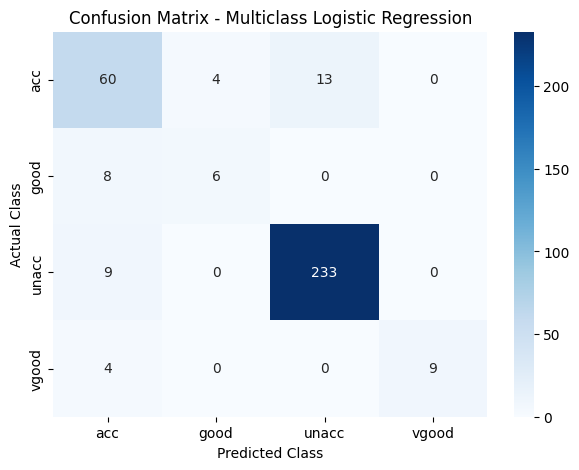

In [ ]:
# Display the confusion matrix as a heatmap

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Multiclass Logistic Regression")

plt.show()
